In [7]:
# not all of these imports are used in this notebook, but I use them throughout my work and you may find them useful eventually!
import numpy as np
import pandas as pd
import h5py
import vaex
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import matplotlib.colors as colors

from astropy import units as u
from astropy.io import ascii,fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions as fn 
# this is a script of functions I wrote myself for this work, you will only be using a couple of them but if you are interested in seeing how signal files are generated or how the background is sampled, take a look!

np.random.seed(0)

# Dwarf Galaxy Stellar Halo Starter Notebook

Hello! Welcome to the starter notebook for our project! We are trying to understand how orientation changes the detectability of stellar halo substructure around dwarf galaxies. That may sound line nonsense for now, but hopefully by the end of this notebook we can build some intuition and understanding about what we are trying to do and how we are going to do it. 

I recomend making a new python environemnt for this, I always do when starting a new project. You don't necessarily need to, and if you are not sure how I can help.

Also, much of this work requires variables that are strings of the paths to your data. These are different for you than they are for me, so make sure to change them when you see them or else this notebook will not run!

## Reading in data 
First, we need to access the data. I will be reading in the ananke outputs of Storm 2 (year 10, 2 Mpc), one of the galaxies in our sample. Remember: there is no background in here yet, this is just the simulated points that I split into individual stars using ananke.

In [10]:
box = 'storm' # the boxes are 'rogue', 'elektra' 'storm' and 'MM' (for Marvelous Massive)
num = 2 # number of our galaxy within the box
D = 2000 # 2000 kpc is 2 Mpc
mlim_str = '26p5' # 26.5 is the depth of the yr 10 survey, i had to do p instead of . because ananke got mad at there being a decimal in the name of one of the galaxies. weird
name = f'{box}_4096_{num}_data_{D}_{mlim_str}' 

# this is the path to the galaxy, change this to be where you put your data! I used an f-string and some {} to put my variables in here so it is easy to read in different catalogs
dwarfcatpath = f"/home/otteleno/MAP/matched_filter_starters/{box}_{num}_data/survey.{name}.0.h5" 

# these are read in with vaex, which i convert to a pandas dataframe since i am more familar with them 
vdwarfcat = vaex.open(dwarfcatpath)
dwarfcat = pd.DataFrame(vdwarfcat,columns=vdwarfcat.column_names)

# look at all that information! lets make some plots
dwarfcat


,age,dec,dmod,feh,glat,glon,grav,lsst_g,lsst_g_Err,lsst_g_Intrinsic,...,py,pz,ra,rad,smass,teff,vr,vx,vy,vz
0,5.790941,-27.289413,26.505910,-3.353632,-89.838794,-58.435505,4.630040,24.973608,0.0,-1.532301,...,-4.796306,-2000.692459,12.863807,2000.700378,8.469514,30391.779297,22.424863,-15.012797,-118.182710,-22.163740
1,5.790941,-27.288862,26.505966,-3.353632,-89.839341,-58.489424,4.641106,25.128321,0.0,-1.377645,...,-4.782901,-2000.744140,12.863962,2000.752006,7.995754,29654.767578,22.711874,-14.970212,-117.942916,-22.451953
2,5.790941,-27.286993,26.505830,-3.353632,-89.841203,-58.591757,4.678921,25.665352,0.0,-0.840478,...,-4.732338,-2000.619082,12.864229,2000.626766,6.477076,26965.000000,22.309659,-14.936937,-118.317029,-22.051448
3,5.790941,-27.288070,26.505883,-3.353632,-89.840177,-57.554448,4.704493,26.048357,0.0,-0.457527,...,-4.709607,-2000.667868,12.861004,2000.675652,5.550234,25086.126953,22.424281,-14.807811,-118.348043,-22.167936
4,5.790941,-27.289710,26.505906,-3.353632,-89.838500,-58.381519,4.394523,22.729784,0.0,-3.776121,...,-4.802262,-2000.688145,12.863643,2000.696092,21.333363,42878.335938,22.726916,-15.012905,-118.214109,-22.465441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276384,10.072595,-26.779000,26.495388,-1.231300,-89.650697,121.950746,2.083633,27.048178,0.0,0.552790,...,10.299319,-1990.991771,12.852778,1991.028771,0.841396,4841.669922,-14.144604,-50.328127,-165.952707,13.448771
276385,10.072689,-26.743475,26.495769,-1.238766,-89.612804,116.513608,0.443303,25.110546,-0.0,-1.385223,...,12.042001,-1991.333299,12.811010,1991.378770,0.842181,3946.756104,-14.839596,-49.814425,-161.079507,14.016135
276386,10.073256,-26.960854,26.497580,-1.077599,-89.832120,127.274086,1.573500,26.327957,-0.0,-0.169623,...,4.646928,-1993.031053,12.873738,1993.039608,0.850544,4515.127441,-13.319804,-44.434561,-195.750620,12.942301
276387,10.073727,-27.040387,26.496199,-1.075377,-89.801335,-173.271817,1.724962,26.549034,-0.0,0.052835,...,-0.809125,-1991.761102,13.059603,1991.773075,0.850442,4598.263184,17.371433,-33.724327,-193.655836,-17.176738


Text(0, 0.5, 'kpc')

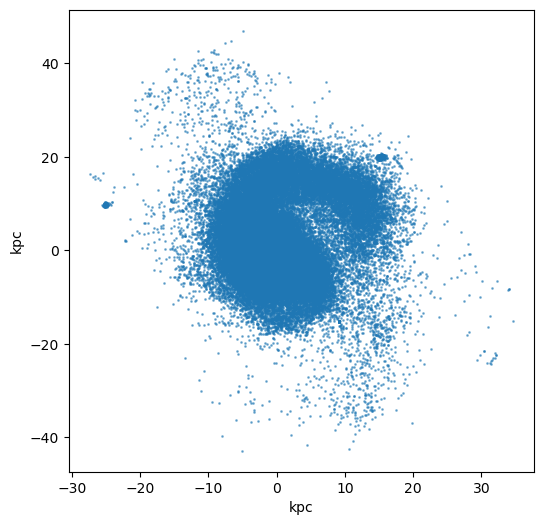

In [9]:
# this look familiar? 
fig = plt.figure(figsize=(6,6))
plt.scatter(dwarfcat['px'],dwarfcat['py'],s=1,alpha=0.5) # s changes points size, alpha changes point transparency

plt.xlabel('kpc')
plt.ylabel('kpc')

# since this galaxy is neatly contained within a box that is about 60 kpc to a side, we define the variable pdist down below to reflect that

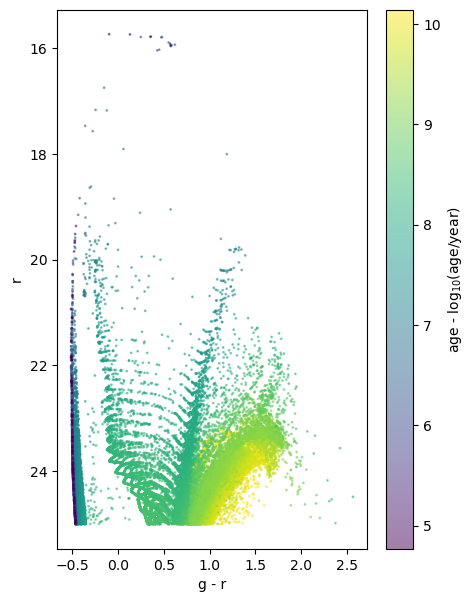

In [5]:
# what does the CMD look like? 
fig = plt.figure(figsize=(5,7))
cbar = plt.scatter(dwarfcat['lsst_g'] - dwarfcat['lsst_r'],dwarfcat['lsst_r'],c=dwarfcat['age'],s=1,alpha=0.5)
plt.colorbar(label=r'age - log$_{10}$(age/year)') # old is yellow, young is purple
plt.gca().invert_yaxis() # magnitudes are backwards!
plt.xlabel('g - r')
plt.ylabel('r');
# what do you see in here? can you identify different stellar evolutionary stages? 

You can make CMDs in any filter combination, however we use g and r here since those are the filters we have background information in. LSST itself will have 6 filters, but because of the background of it all we are limited to 2 in our analysis. 

## Combining with the background field
Lets now combine the above data table with some background galaxies into a new table. I wrote a function for this, which you can edit as much as you would like to make your life easy. It is possible (if not likely) that I am doing something inneficently, or maybe I wrote a bug into here that I didn't catch. Make sure you know what each step of the process is doing, and why we are doing it!

This function also adds in realistic photometric error to the simulated points, wiggling them around in g and r based on the predicted error for LSST. It does not wiggle the background points, since they are sampled from real data which are intrinsically wiggled from the error of the instrument that took the data. It was bad practice for me to include this in this larger function instead of writing a function for it seperately, but here we are. If you want to change this, go right ahead!

Also, if this function is not what you want to do (I am only worrying about one orientation and I wrote the function to reflect that) make your own! There may be a better solution to your specific research case than what I have done before. However, this is a good place to start, and is fairly simple to change if you know where to edit for your own work.

In any case, editing this process so that you can change how the simulated galaxy is orientied and then projecting it onto the background points is where I beleive your work comes in.

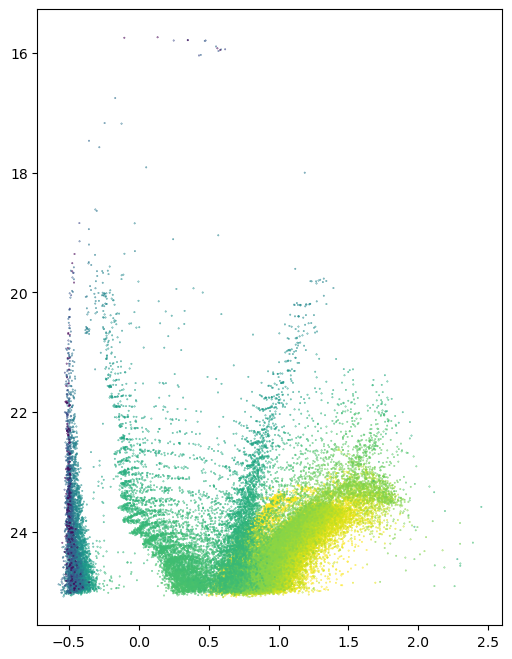

Saving ... 


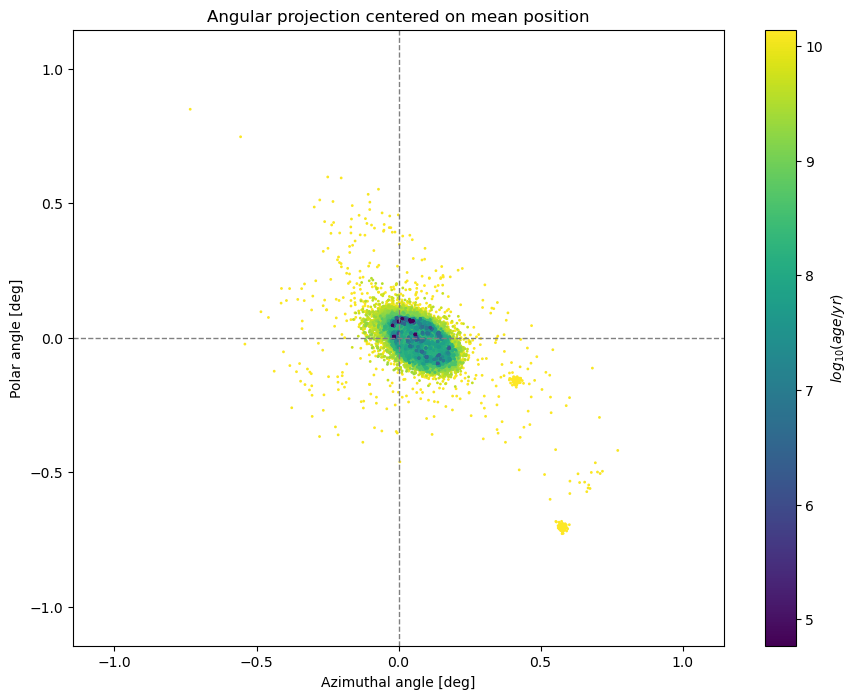

In [6]:
size_kpc = 40 # length of one edge of the plot in kpc - edge length of the plots based on the first plot in this notebook
pdist = (size_kpc/D) * (180/np.pi) # converting the above into degrees (on the sky) instead of kpc
year = 10
mlim = '25'
c1='px'
c2='py'
edgelength = 10 # size of the bg field that I generated, this is (unecessarily) huge, so if you want a smaller one I can make one 
plotdir = f'{box}_4096_{num}' # folder where you want your plots to go if you are saving them
bgcatpath = f"/home/otteleno/MAP/matched_filter_starters/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"
table_final = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=False,save=True) 
# find the save statement for the table_final in this function, change it to where you want the table to go, and then make save=True

Great! The three plots this outputs are: 

1. A CMD with realistic photometric erros added in. Notice how it gets blurrier as the stars get dimmer! Compare with the CMD we made of the ananke outputs without errors.

2. The map of stars associated with the galaxy (coolor coded by age, centered on the mean position) in angular units instead of kpc. In my case, I am taking the `px` and `py` columns and transforming them into angulur units based on the distance I set of the galaxy (here 2 Mpc). You will notice that the galaxy has rotated slightly from the first plot we made, this (for me) doesn't matter, I did it so that it matched the projection in a gif I was sent of the galaxy evolving. For you it is the name of the game. Somwhere, either in the function I wrote or in your own, you will be changing these rotations intentionally and making a set of these tables, one for each orientation. 

3. The third plot has the simulated galaxy in blue, with the background sources in orange. This is just to check and see that the galaxy is in there and surrounded completly by background sources.

These plots are diagnostic, and were what I needed at the time of writing this fucntion to make sure it was working properly. You may need/want different plots, so feel free to play! 

Make sure these tables you make are saved to the computer you use, as the matched filter function reads in the data for you instead of taking the table in as a variable. You can also edit the function to take in tables if that is easier for you!


In [14]:
# take a look at the table 
table_final
# flag tells us where the particle originated (in the dwarf is dw, in the background is bg)
# you can mask the points with the above flag to make diagnostic plots if you want
# age is the age of the stars, I set the ages of the galaxies to be -99 so i know they are not useful and are easy to mask if i need to 

c1,c2,gmag,Ag,rmag,Ar,flag,age
float64,float64,float64,float64,float64,float64,str2,float64
0.08916621116570993,-0.006398137217840423,24.485165755130968,0.0,23.528033942534613,0.0,dw,10.141212463378906
0.4156535125898207,-0.1630593132602482,25.32063646394277,0.0,24.604468686935995,0.0,dw,10.141212463378906
0.09108342790290447,-0.022202432981751712,24.824868936826412,0.0,23.943451235278765,0.0,dw,10.141185760498047
-0.030615102310421877,0.04133317161921468,25.047185792887724,0.0,24.28568773367068,0.0,dw,10.141131401062012
0.04420549234283678,-0.015913350351768753,24.491211154953714,0.0,23.436000083516753,0.0,dw,10.139671325683594
0.06142654634523783,-0.0022696874859153868,25.177698504396933,0.0,24.32692524246505,0.0,dw,10.139671325683594
0.03934259765884894,0.03725628023636318,25.27171165381166,0.0,24.653967910908214,0.0,dw,10.139671325683594
0.0412392100367339,-0.061732184774159225,24.81800146349955,0.0,23.993567195275997,0.0,dw,10.139671325683594
0.07010356778436282,-0.0065452851550943155,25.3210256103771,0.0,24.660206053376378,0.0,dw,10.139671325683594


Lets look a the combined source catalog now, both in the sky and in a CMD:

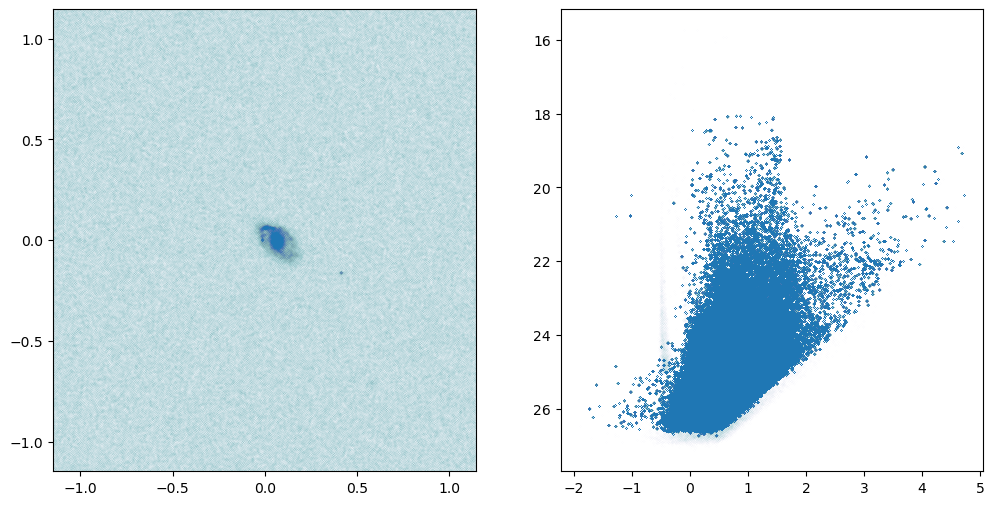

In [15]:
fig,axs = plt.subplots(nrows=1,ncols=2)
fig.set_figheight(6)
fig.set_figwidth(12)

# only plotting every other point, since there are so many. so many background galaxies that look like stars!
axs[0].scatter(table_final['c1'][::2],table_final['c2'][::2],s=0.01,alpha=0.05) # gotta make the points tiny and super transparent since there are so many!
axs[0].set_xlim(-pdist,pdist)
axs[0].set_ylim(-pdist,pdist)

axs[1].scatter(table_final['gmag'][::2]-table_final['rmag'][::2],table_final['rmag'][::2],s=0.01,alpha=0.05)
axs[1].invert_yaxis()

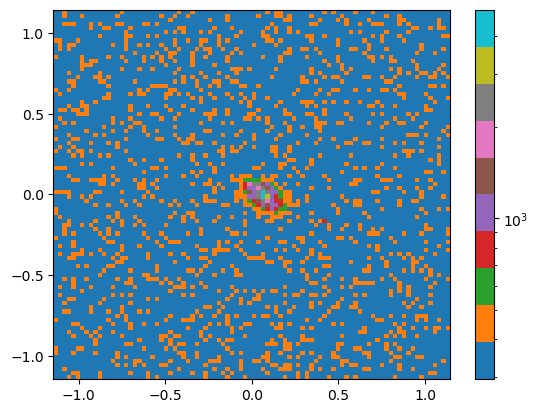

In [16]:
plt.hist2d(table_final['c1'],table_final['c2'],bins=90, norm=colors.LogNorm(), range =[[-pdist, pdist], [-pdist, pdist]], cmap='tab10')
plt.colorbar()

It is obvious that there is a galaxy at the center of the left panel, and we can even pick out a hint of the stream by eye.

This is rarely the case in reality, these streams are super hard to see and blend with the background extremely easily. Look at the CMD! There is so much in there that cannot be stars. Compare with the simulated points only to see what I mean.
 
There are some simple and clever ways to pick out features like this, using boxes in the CMD space to define a mask where RGBs or AGBs or Main Sequence stars live, but this is never optimal since background galaxies populate these regions too. They talk about this in the matched filter paper I sent if you are interested more in that methodology. In much of my previous (and current) work, I use this non-optimal method with varying degrees of success. This is where the matched filter comes in - how can we determine what is a star and what isn't in a more optimal way, and where do those points we deem to be stars live on the sky?

If you want to play around, I can send some code later that shows how to pick out sources in the CMD using a matplotlib Path object to define a mask, but since we aren't using that method for the matched fitler, I will not add it here. 

## Signal Files

For the matched filter to work, we now need to define our signal. This is fairly simple, as I have sent you the necessary singnal files (old + metal poor stellar population) for now. However, I added this in case you want to change your singal file later and need a place to start. I will need to send isochrones and luminosity functions for this to work, but you can also generate them [here](https://stev.oapd.inaf.it/cgi-bin/cmd) if you so choose. This webpage is hard to parse and there are a lot of options, so if this is a path you choose to go down let me know and we can set up a meeting for a isochrone generation tutorial. 

In [17]:
age = '10'
mh = '-2'
#fn.signal_gen(name=name,num=num, box=box,year=year,age=age,mh=mh,D=D*1000,plot=True) # D in pc

And there it is! A single, old, metal poor stellar population. These points are also wiggled by the photometric error, since our signal (the stars in the galaxy) will have this error associated with them. Our "pure" signal must include this error, since the actual points we are observing are not perfectly where they should be in CMD space. Strangely, in our science case "noise" is the background galaxies, not the measurement errors. 

These will also need to be saved to a directory on your machine, and read in by the matched filter function when you run it. 

## Matched filter detection

We have reached our destination of using the matched filter. Again, a function for this has been defined, but I reccomend reading through that script (after or during when you read the paper I sent [here](https://iopscience.iop.org/article/10.1086/340957/pdf)) to understand how this works. It is hard to parse, but with practice and time you will become an expert. 

In [19]:
from matched_filter_ani import matched_filter_ani as mf

iso_info = 'parsec' 
rmaglim=26


numpix = 100
pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
catalog=f'/home/otteleno/MAP/matched_filter_testing/catalogs/' + name + f'_{c1}{c2}_formf_bg{edgelength}deg.fits'
field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'

mf(plotdir=f"../plots/{plotdir}/",
    field=field, 
    catalog=catalog, 
    signal_file=f"/home/otteleno/MAP/matched_filter_starters/signal_files/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt", 
    plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60, galaxy_name ={box}_{num})

# this will take a few minutes to run, especially in the notebook format. On my machine, it took about 10 minutes, and I am using a remote machine much more powerful than my laptop
# I recommend runnning the function in the terminal for actual research purposes - speeds things up and is easier to iterate if you change the functions
# the runtime will vary as well based on the number of pixels you choose to use and other knobs you may want to turn 

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2460113700.py, line 16)

These plots show:
1. The points in the signal file in CMD space. These are the points made using the isochorne and luminosity function, binned by a size you set within the matched filter script. Play with this if you like, but this bin size has been working well for me. 

2. The same as the above, but for noise. Make sure the sizes for the signal bins and noise bins are the same! IF they aren't, there is no way to see how good or bad a given point's weight is, since we cannot comapre the same exact places in the CMD, and the code will throw and error.

3. The histogram of each on-sky bin's weights. Those in orange are the bins close to the modal value, these are your 'sky' or 'noise' bins, and their values define what noise looks like in our matched filter maps. The blue bins are the 'signal' bins, there are bins containing sources whose weights are $X\sigma$ away from the median value. This plot was super useful for me when I was learning how this function works. You want there to be a good number of blue ones to the right of the orange peak, and you can edit the pixel size, signal files, CMD bin sizes, etc. to make this plot and the resulting matched filter map change. 

4. The actual matched filter map. Look at that! It is much better than the scatter plot we made of the points, and more of the stream structure is popping out. The difference will look a lot more dramatic for galaxies whose stellar halos are not as obvious as Storm 2.

Matched fitler is a powerful technique, but it has a lot of knobs to turn and a lot of moving parts that can be hard to understand. Playing with this and watching how the three diagnostic plots change with repect to the final map helped me a lot to build intuition.

Also, when you compare this map with only the sumualted points, it is clear that we do not detect everything. This is good news! Real life observations of resolved stellar popualtions $\emph{never}$ see everything, espcially in our research case where we are looking at the diffuse, low surface brightness features around small galaxies. Since we are trying to emulate these real-life images it makes sense that we only see some subset of what is actually there. 

## All Done!

And thats pretty much it! This notebook contains an overview of about six months of my life, and I do not expect you to understand every detail after one run-through. 

If you are reading through this and think it's a lot, good news! You're right. But you will learn! That's what it is all about. I was sent a very similar notebook to this one (in size and scope, not in content) when I first began research as an undergrad and was quickly overwhelmed and discouraged. Struggling is a part of the learning process, but I am always at your disposal if you need any kind of assistance. I vividly remember being in your shoes, and in many ways I still am.

Please mess with this notebook and the scripts I sent you as much as you want. Break them, fix them, test them, and if you break something beyond repair, just redownload them and start again!